In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import skgstat as skg
from sklearn.cluster import KMeans

plt.style.use('ggplot')

In [2]:
# Load dataset as CSV and print out the first few rows
df = pd.read_csv("../dataset_1_pixels_grid_indices.csv")
print(df.head(10))

   row  col        date  pm25_today  u_wind_10m  v_wind_10m  dew_temp_2m  \
0    0    0  2022-12-27   13.625057    1.294254    0.312046    280.22186   
1    0    1  2022-12-27   12.278015    1.371728    0.206333    281.88910   
2    0    2  2022-12-27   11.339845    1.437077    0.102919    282.60867   
3    0    3  2022-12-27    9.915960    1.468449    0.009372    281.99050   
4    0    4  2022-12-27    8.805679    1.376245   -0.047940    281.41156   
5    0    5  2022-12-27    8.585770    1.284774   -0.104764    281.87958   
6    0    6  2022-12-27    8.825801    1.186792   -0.119717    282.12143   
7    0    7  2022-12-27   10.446621    1.080916   -0.066718    282.21982   
8    0    8  2022-12-27   12.289478    0.978458   -0.000943    283.37436   
9    0    9  2022-12-27   13.280171    0.824853    0.065097    284.76468   

     temp_2m  surf_pressure    precip_sum  frp  elevation  pm25_change  
0  287.84830      86948.180  8.523463e-07  0.0     1360.0    11.219316  
1  289.22437     

### Question 1: is $\Delta PM_{2.5}$ a stationary process?
- Augmented Dickey–Fuller test conducted on mean PM2.5 change (daily) indicates that <br>
$\Delta PM_{2.5}$ is a stationary process.

In [3]:
# how does PM2.5 change over time?
daily_mean_pm25 = df.groupby("date")["pm25_change"].mean()

result = adfuller(daily_mean_pm25.values)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')

for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
    print("\u001b[32mStationary\u001b[0m")
else:
    print("\x1b[31mNon-stationary\x1b[0m")

ADF Statistic: -8.370872
p-value: 0.000000
Critical Values:
	1%: -3.435
	5%: -2.863
	10%: -2.568
Stationary


### Question 2: what is its global temporal autocorrelation?
- ACF plot shows geometric decay with significant correlation at lags 1-3.
- PACF plot shows geometric decay with signficant correlation at lags 1-2.
- Lack of significance tailoff may be due to noise.
- Results suggest either an AR(1)/AR(2) process or an ARMA(1, 1) process.

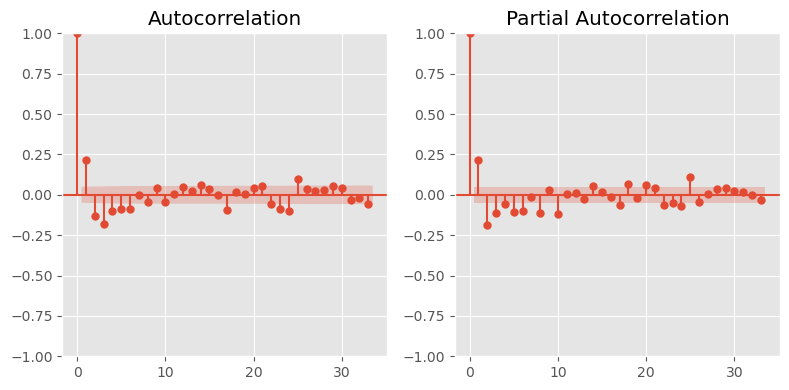

In [4]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
plot_acf(daily_mean_pm25, ax=ax[0])
plot_pacf(daily_mean_pm25, ax=ax[1], method='ols')

plt.tight_layout()
plt.show()

### Question 3: what is its local temporal autocorrelation?
- Used K-means clustering with K=6 to cluster spatial locations by their summary statistics.
- ACF/PACF plots were generated for each cluster medoid.
- Most plots indicate some form of AR or ARMA process.

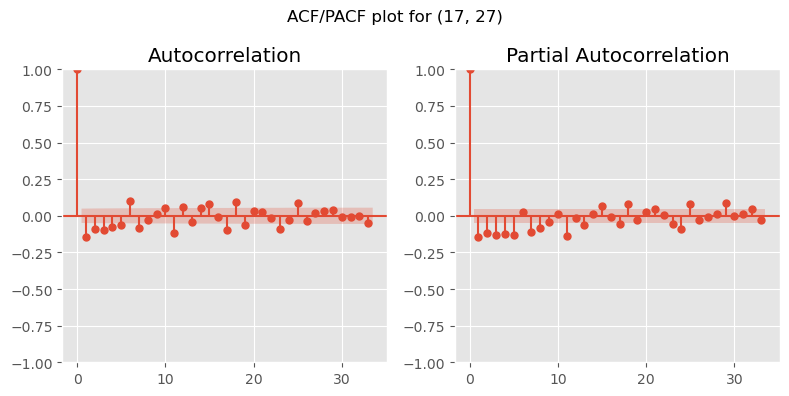

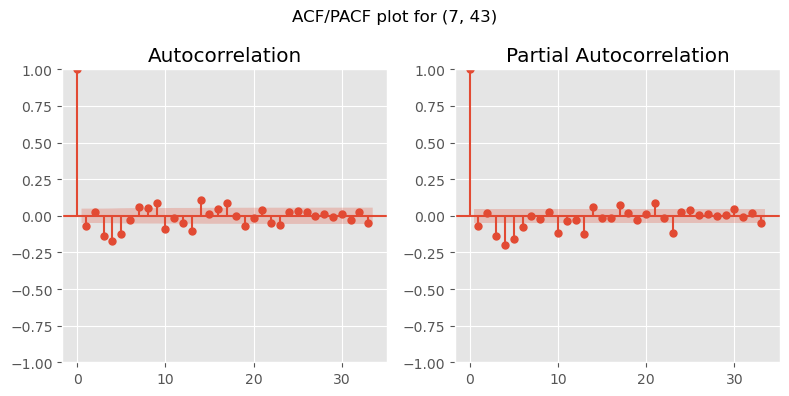

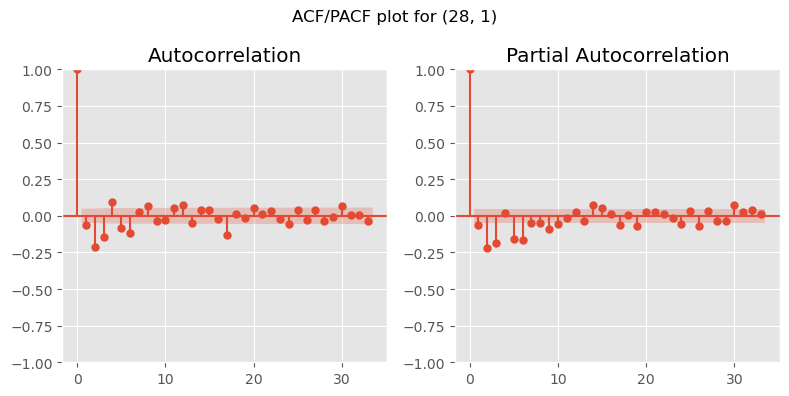

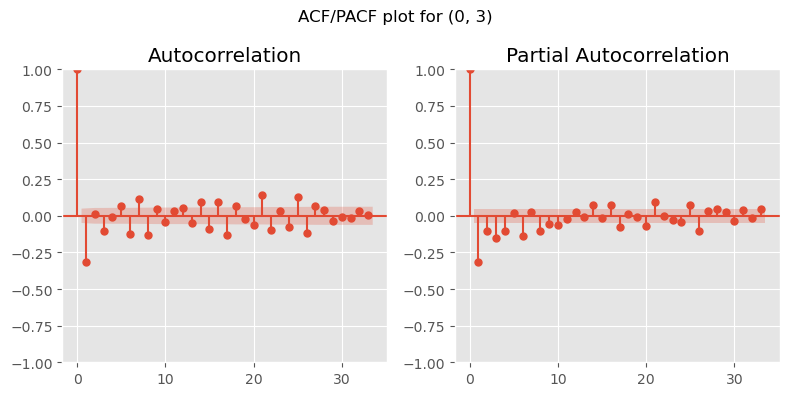

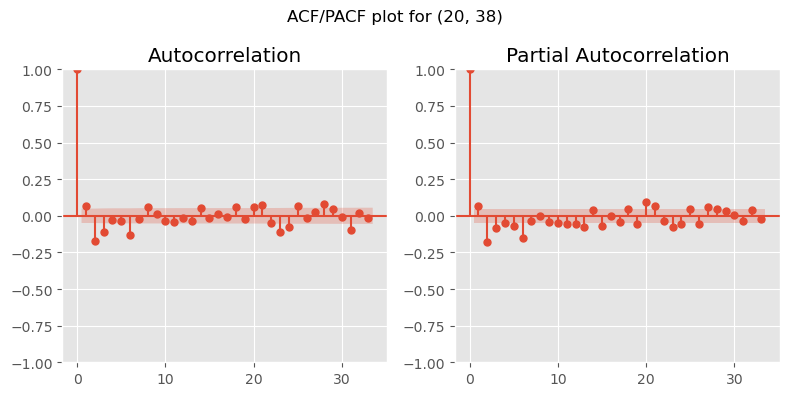

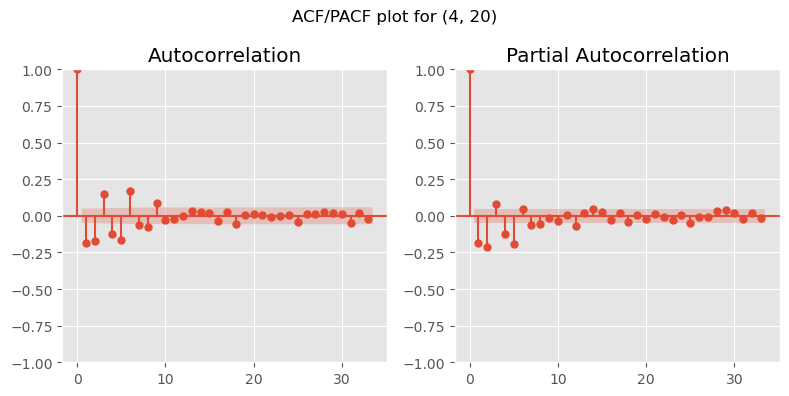

In [5]:
# Get location-based summary statistics
pixel_summaries = df.groupby(["row", "col"])["pm25_change"].describe().drop("count", axis=1)
K = 6
kmeans = KMeans(n_clusters=K, random_state=191)
pixel_summaries['cluster'] = kmeans.fit_predict(pixel_summaries.values)


medoids = []
for i in range(K):
    mask = pixel_summaries['cluster'] == i
    center = kmeans.cluster_centers_[i]
    points  = pixel_summaries.loc[mask].drop("cluster", axis=1).values
    idxs    = pixel_summaries.index[mask]
    dists   = np.linalg.norm(points - center, axis=1)
    medoids.append(idxs[np.argmin(dists)])

for i in range(len(medoids)):
    row, col = medoids[i]

    mask = (df["row"] == row) & (df["col"] == col)

    sub = df.loc[mask, ['date', 'pm25_change']].copy()

    sub['date'] = pd.to_datetime(sub['date'])

    ts = sub.set_index('date').sort_index()

    f, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    f.suptitle(f"ACF/PACF plot for ({row}, {col})")
    plot_acf(ts, ax=ax[0])
    plot_pacf(ts, ax=ax[1], method='ols')
    
    plt.tight_layout()
    plt.show()

In [6]:
# Create a full date range
all_dates = pd.date_range(start='2018-07-04', end='2022-12-30', freq='D')

# Randomly sample N days (e.g., 5)
sampled_dates = np.random.choice(all_dates, size=50, replace=False)

ranges = []

for date in sampled_dates:
    date_str = str(date)[:10]
    df_filtered = df[df["date"] == date_str]
    if len(df_filtered) == 0:
        continue

    coords = df_filtered[['col', 'row']].to_numpy()  # order = (x, y)
    values = df_filtered['pm25_change'].to_numpy()

    V = skg.Variogram(
        coords,
        values,
        model='gaussian',
        estimator='cressie',
        maxlag=44         # max distance in grid units
    )

    range_ = V.parameters[1]
    ranges.append(range_)
    print(date_str, range_)

print(np.percentile(ranges, 50))

2022-08-30 1.0299675663664838
2019-04-11 174.3159993054215
2018-10-27 4.674104156811824
2019-03-14 923.2634059165815
2021-08-26 1.60377831241415
2022-09-08 11.113634695771935
2019-01-25 33.492975511524534
2019-04-16 102.8381227764018
2019-10-02 43.5898489858639
2021-08-04 2.6748561818736274
2019-05-28 8.276537241590194
2018-09-26 0.21939057734561182
2021-08-28 0.5059995097784704
2021-10-27 11.338483298828788
2018-12-07 15.881095366984265
2021-12-26 26.40189598217723
2019-05-20 28.74459531462309
2021-12-24 21.4920949457418
2022-02-15 26.165520392430142
2020-08-31 5.631806137477507
2020-09-24 1.0879276538218194
2022-01-12 13.885101624812084
2019-12-08 4.903602108978295
2018-08-31 1.5239147473742076
2019-08-20 0.7551744686088893
2021-06-11 0.38782096402254423
2018-07-28 0.7700713882015033
2022-10-30 6.691673139613123
2019-04-25 26.03016669867404
2019-02-17 94.65665659797261
2021-07-20 0.4302932762406374
2019-10-09 1.086934191139244
2018-08-25 0.4908339625355716
2022-01-16 29.8821680778643